#**Chi-Square Test of Independence**

## **The Scenario**
Marketing and Design Team comes up with a New Packaging for a Dog Food Company.
Everyone in the team agrees that it's Unique and they love it. But, since the packing is heavier the Product Manager is worried whether it would increase the Sales of the Product as well or, it would just create problems during delivery and distribution.

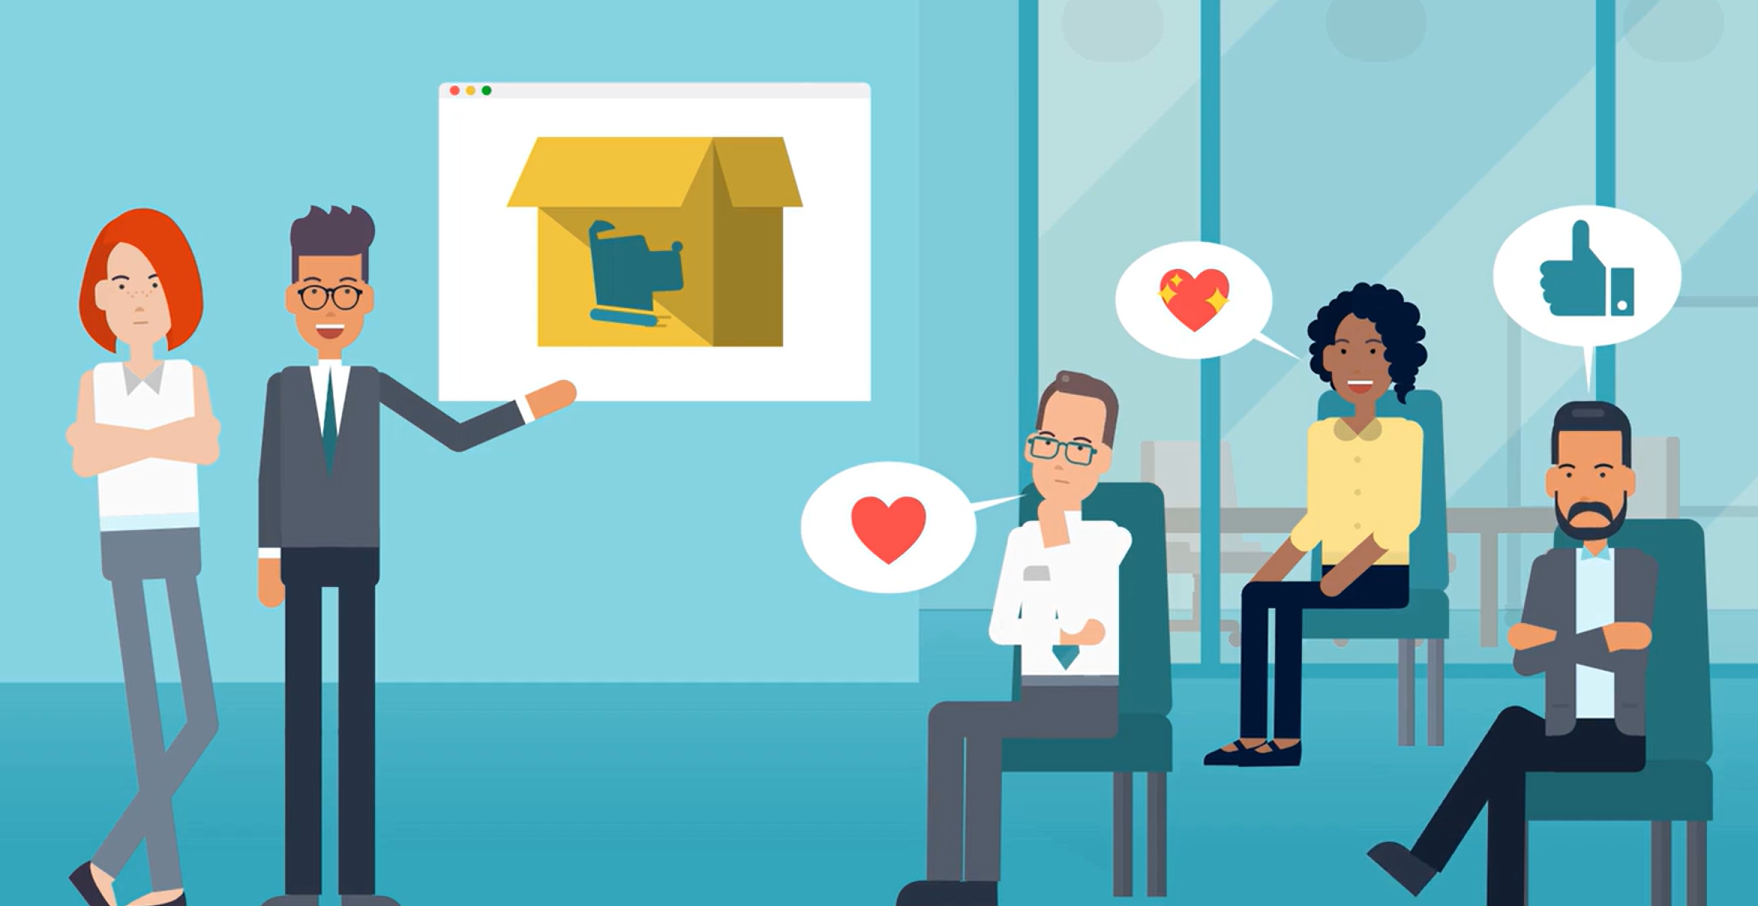

**So, to find out the answer they opted for a Survey with 523 respondents/customers.**

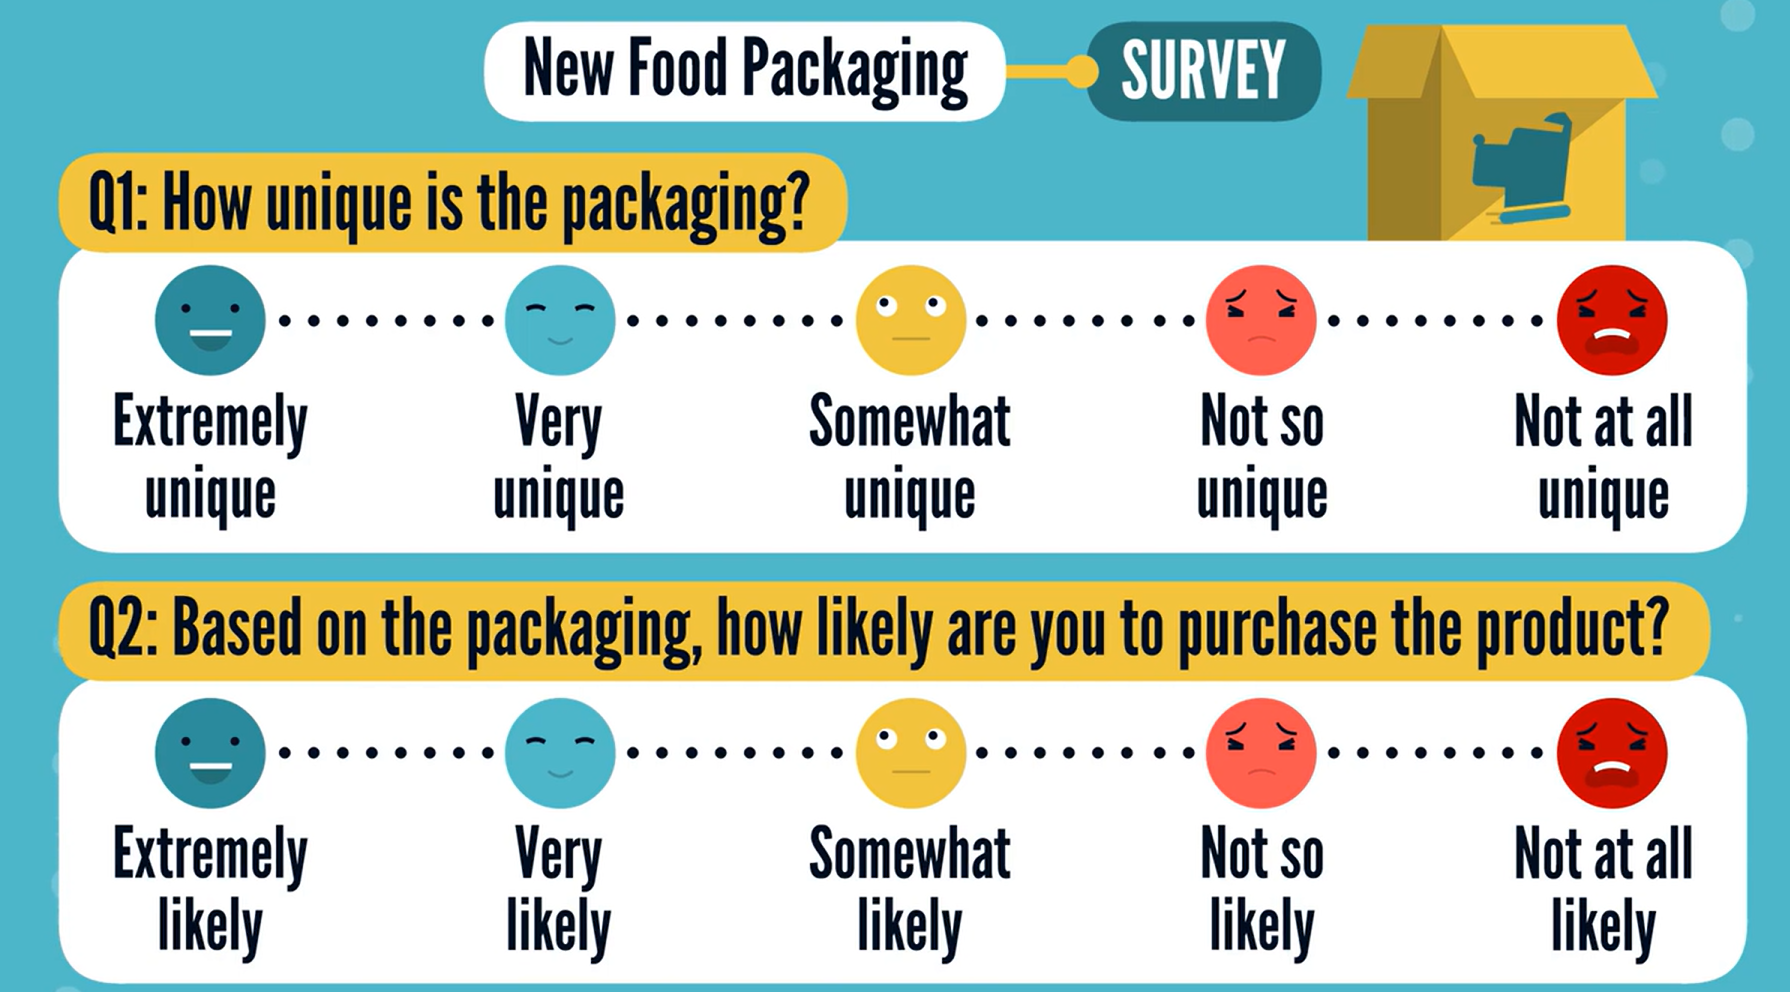

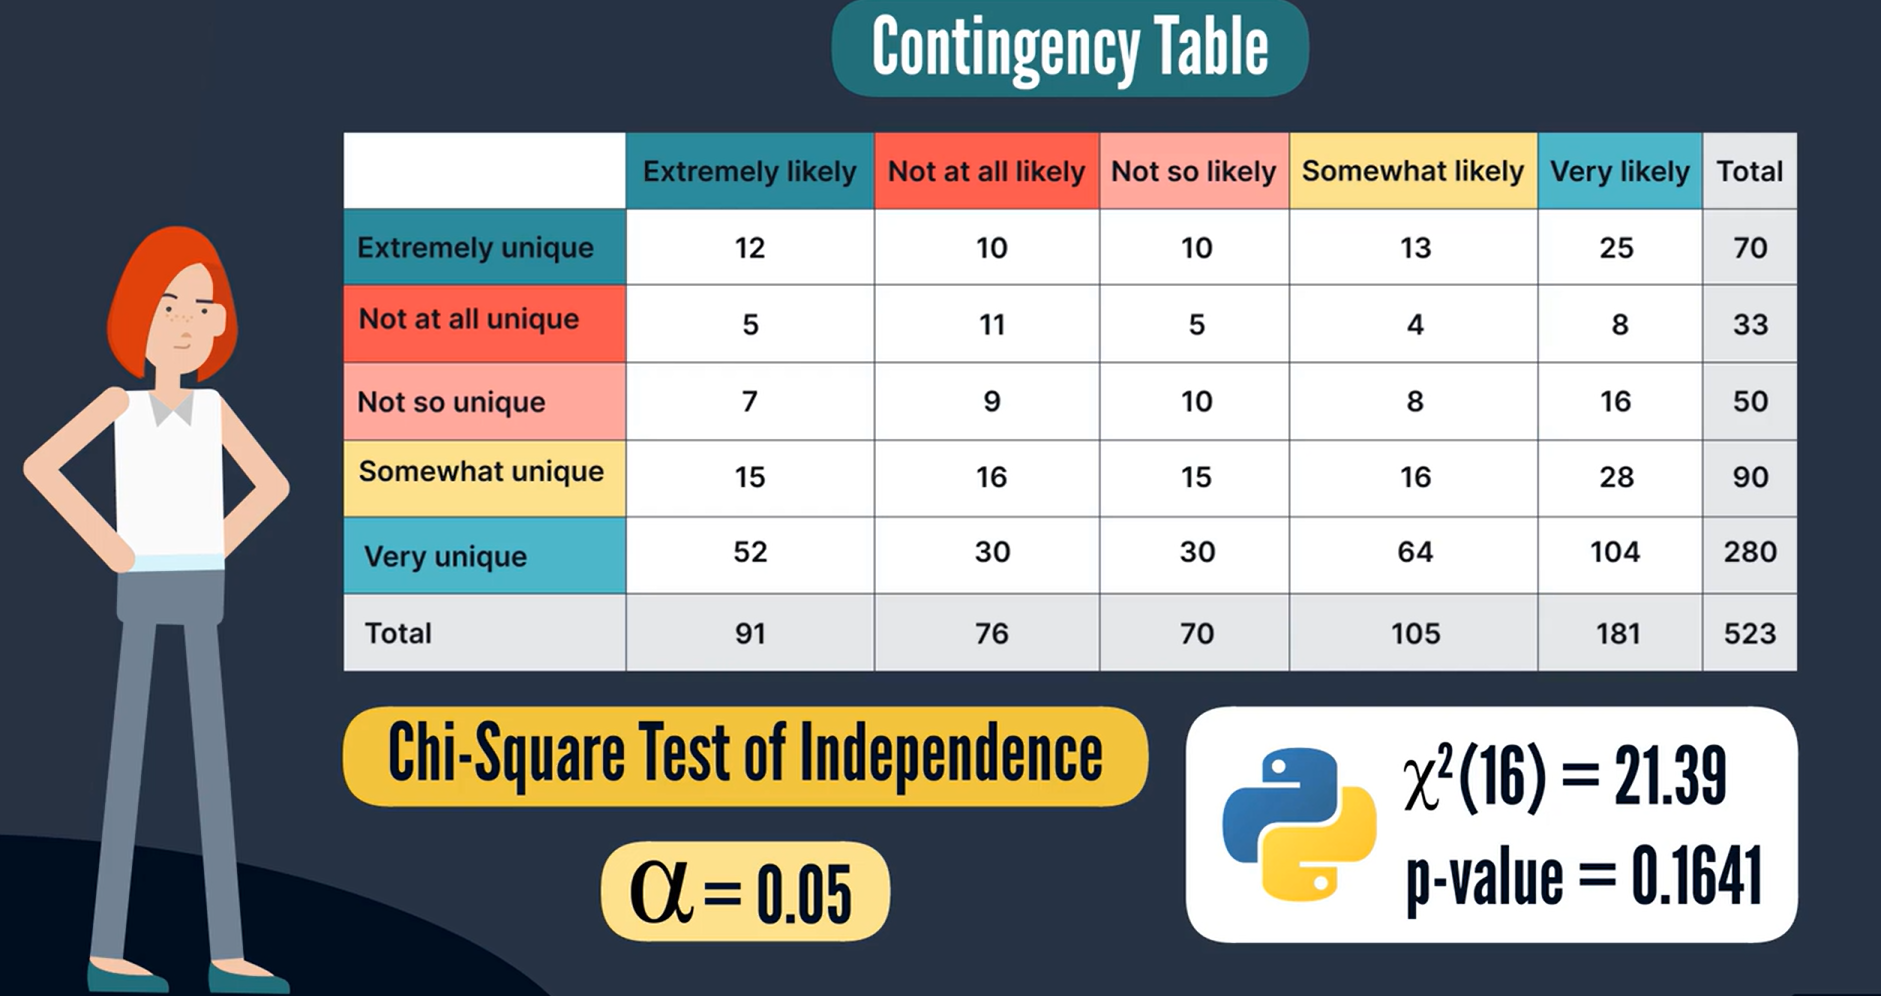

## **Importing the Necessary Libraries and Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [ ]:
#load file
from google.colab import files
files.upload()

Saving Case 1 - Chi-square test of independence.xlsx to Case 1 - Chi-square test of independence.xlsx


{'Case 1 - Chi-square test of independence.xlsx': b'PK\x03\x04\x14\x00\x06\x00\x08\x00\x00\x00!\x00\xc7z\x97\x90u\x01\x00\x00 \x06\x00\x00\x13\x00\x08\x02[Content_Types].xml \xa2\x04\x02(\xa0\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\

In [ ]:
df = pd.read_excel("Case 1 - Chi-square test of independence.xlsx")

In [ ]:
# Print data head
df.head()

,Respondent,Uniqueness,Purchase Likelihood
0,1,Extremely unique,Extremely likely
1,2,Extremely unique,Extremely likely
2,3,Extremely unique,Extremely likely
3,4,Extremely unique,Extremely likely
4,5,Extremely unique,Extremely likely


In [8]:
# Step 5: Check for missing values
df.isnull().sum()

,0
Respondent,0
Uniqueness,0
Purchase Likelihood,0


In [9]:
# Step 6: Value counts for EDA
df['Uniqueness'].value_counts()
df['Purchase Likelihood'].value_counts()

,count
Purchase Likelihood,
Very likely,181
Somewhat likely,105
Extremely likely,91
Not at all likely,76
Not so likely,70


In [10]:
#Step 7: The Pandas crosstab function can be used to produce the contingency table from the raw data of responses
df_crosstab = pd.crosstab(df["Uniqueness"],df["Purchase Likelihood"])
df_crosstab

Purchase Likelihood,Extremely likely,Not at all likely,Not so likely,Somewhat likely,Very likely
Uniqueness,,,,,
Extremely unique,12,10,10,13,25
Not at all unique,5,11,5,4,8
Not so unique,7,9,10,8,16
Somewhat unique,15,16,15,16,28
Very unique,52,30,30,64,104


<ipython-input-12-2fafea482e86>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Uniqueness', order=df['Uniqueness'].value_counts().index, palette='viridis')
<ipython-input-12-2fafea482e86>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Purchase Likelihood', order=df['Purchase Likelihood'].value_counts().index, palette='mako')


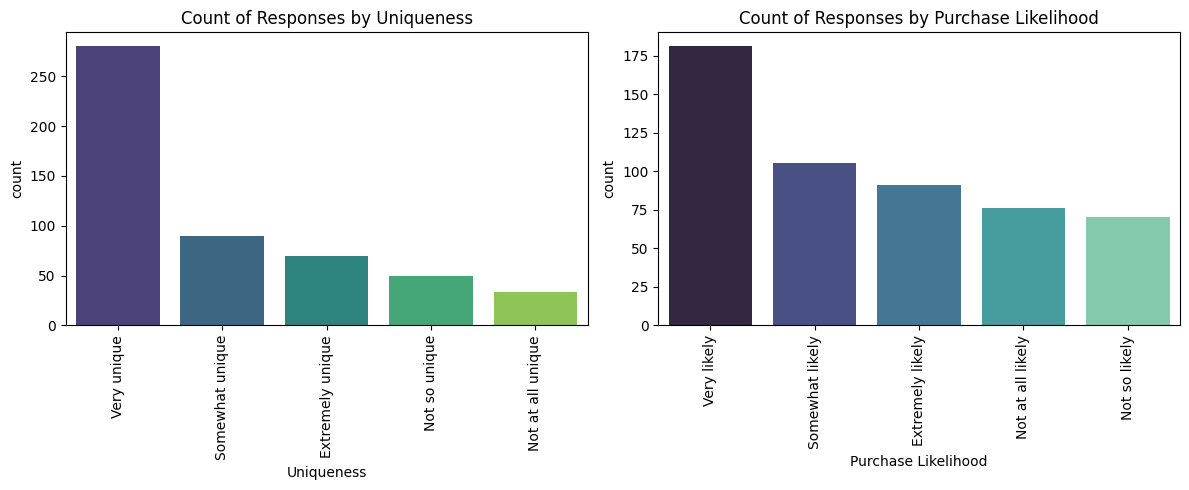

In [12]:
#Step 8: Bar plots of both features
import seaborn as sns # Import the seaborn library
import matplotlib.pyplot as plt # Import the matplotlib library

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(data=df, x='Uniqueness', order=df['Uniqueness'].value_counts().index, palette='viridis')
plt.xticks(rotation=90)
plt.title('Count of Responses by Uniqueness')

plt.subplot(1,2,2)
sns.countplot(data=df, x='Purchase Likelihood', order=df['Purchase Likelihood'].value_counts().index, palette='mako')
plt.xticks(rotation=90)
plt.title('Count of Responses by Purchase Likelihood')
plt.tight_layout()
plt.show()

In [14]:
# Step 9: Create Contingency Table
df_crosstab = pd.crosstab(df["Uniqueness"], df["Purchase Likelihood"])

In [15]:
# Sorting for consistency
sorter = ["Extremely likely","Very likely","Somewhat likely","Not so likely","Not at all likely"]
sorter2 = ["Extremely unique","Very unique","Somewhat unique","Not so unique","Not at all unique"]
df_crosstab = df_crosstab.loc[sorter2]
df_crosstab = df_crosstab[sorter]
df_crosstab

Purchase Likelihood,Extremely likely,Very likely,Somewhat likely,Not so likely,Not at all likely
Uniqueness,,,,,
Extremely unique,12,25,13,10,10
Very unique,52,104,64,30,30
Somewhat unique,15,28,16,15,16
Not so unique,7,16,8,10,9
Not at all unique,5,8,4,5,11


In [17]:
# Step 10: Contingency Table (styled)
df_crosstab.style.background_gradient(cmap='Blues',vmin = 0,vmax = 100)

Purchase Likelihood,Extremely likely,Very likely,Somewhat likely,Not so likely,Not at all likely
Uniqueness,,,,,
Extremely unique,12,25,13,10,10
Very unique,52,104,64,30,30
Somewhat unique,15,28,16,15,16
Not so unique,7,16,8,10,9
Not at all unique,5,8,4,5,11


## **Create Contingency Table**

In [21]:
# Step 11: Proportions Table
# Create contingency table in proportions using "normalize=True" in crosstab function
df_proportions = pd.crosstab(df["Uniqueness"],df["Purchase Likelihood"],normalize=True)

# Sort dataframe
df_proportions = df_proportions.loc[sorter2]
df_proportions = df_proportions[sorter]

# Print contingency table with cells coloured according to magnitude
df_proportions.style.background_gradient(cmap='Blues',vmin = 0,vmax = 0.2)


Purchase Likelihood,Extremely likely,Very likely,Somewhat likely,Not so likely,Not at all likely
Uniqueness,,,,,
Extremely unique,0.022945,0.047801,0.024857,0.019120,0.019120
Very unique,0.099426,0.198853,0.122371,0.057361,0.057361
Somewhat unique,0.028681,0.053537,0.030593,0.028681,0.030593
Not so unique,0.013384,0.030593,0.015296,0.019120,0.017208
Not at all unique,0.009560,0.015296,0.007648,0.009560,0.021033


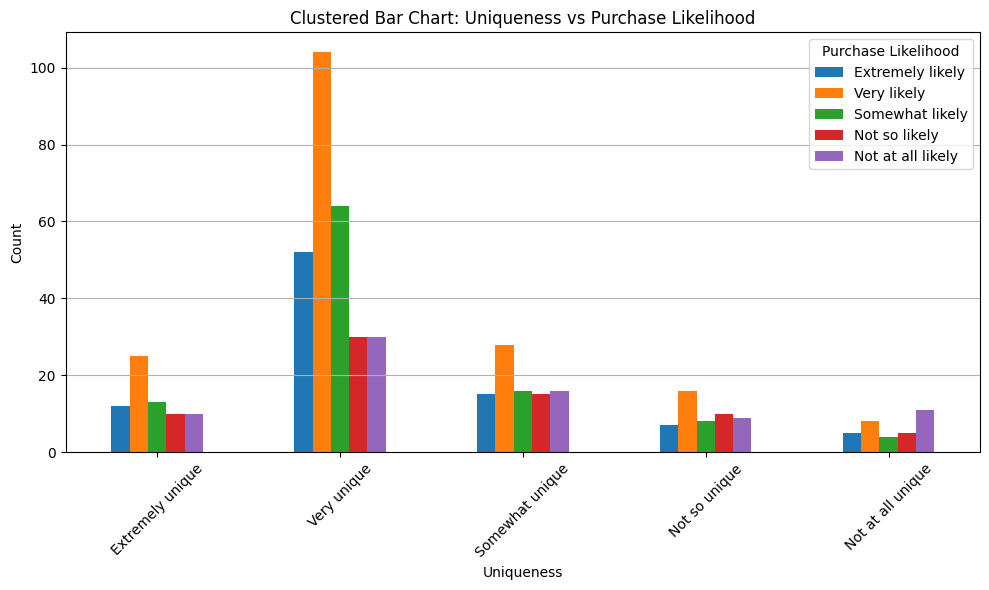

In [22]:
# Step 12: Clustered Bar Plot to visualize
df_crosstab.plot(kind='bar', figsize=(10,6))
plt.title('Clustered Bar Chart: Uniqueness vs Purchase Likelihood')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Purchase Likelihood')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

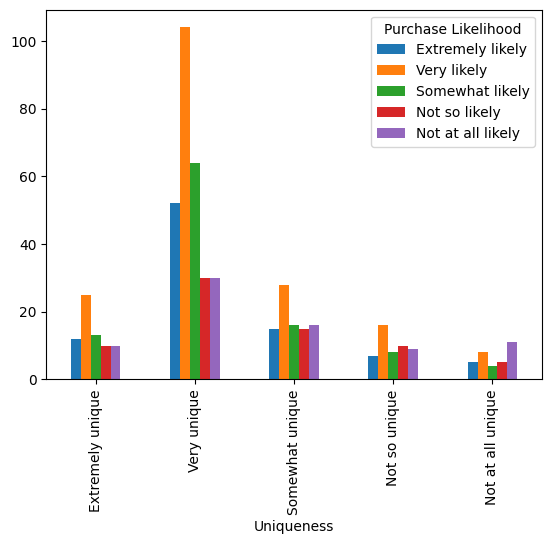

In [ ]:
# Step 12: Plot clustered bar chart to visualize
df_crosstab.plot.bar(rot=0)
plt.xticks(rotation=90)
plt.show()

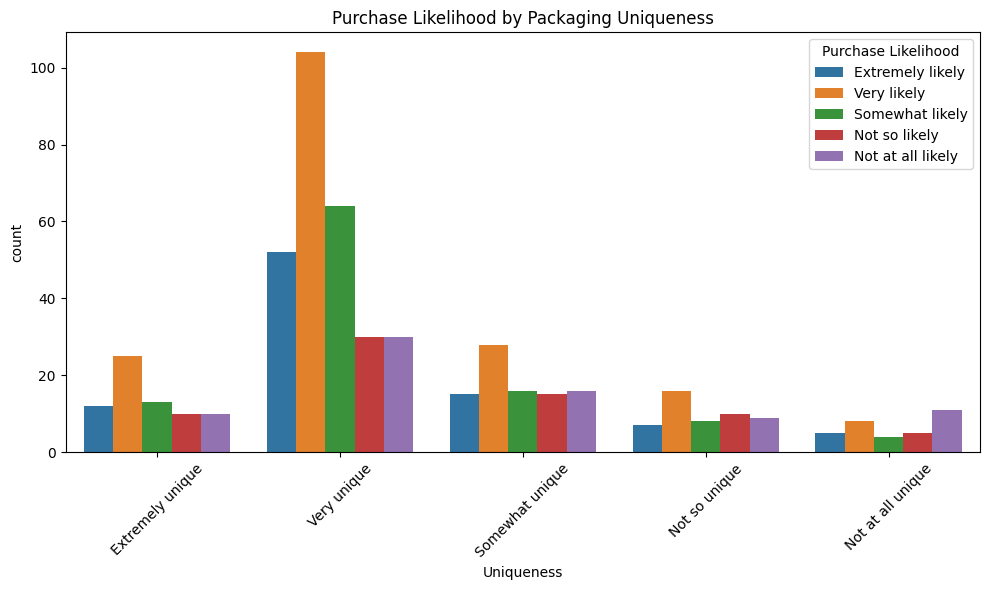

In [23]:
# Step 13: Countplot by Uniqueness → Purchase Likelihood
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Uniqueness', hue='Purchase Likelihood', order=sorter2, hue_order=sorter)
plt.title('Purchase Likelihood by Packaging Uniqueness')
plt.xticks(rotation=45)
plt.legend(title='Purchase Likelihood')
plt.tight_layout()
plt.show()

## **Setting up the Hypothesis**

**Our goal is to examine the claim that the uniqueness of the packaging affects the propensity of consumers to buy the product based on the packaging.**Therefore, the null and alternative hypotheses can be formulated as follows:

- H0: **Uniqueness is not associated with 'Purchase intent'**
- H1: **Uniqueness is associated with 'Purchase intent'**
    
The significance level alpha is set to 0.05.

We can now run the test.

## **Why Chi-square Test?**

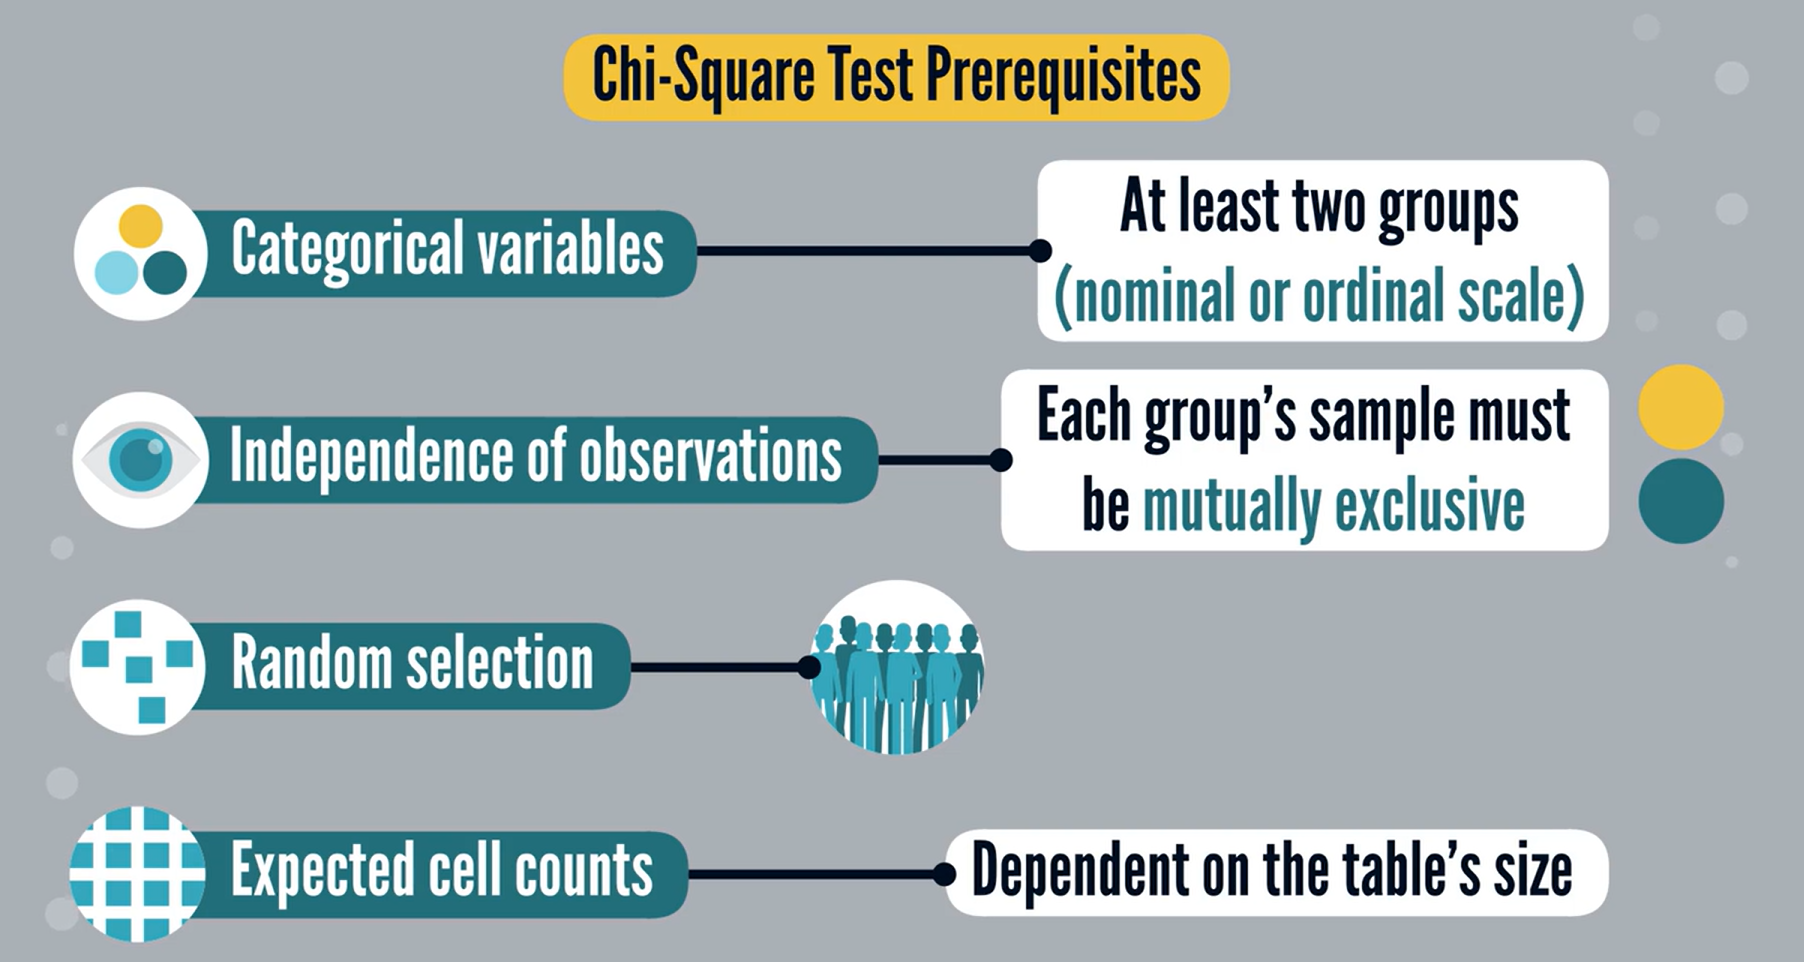

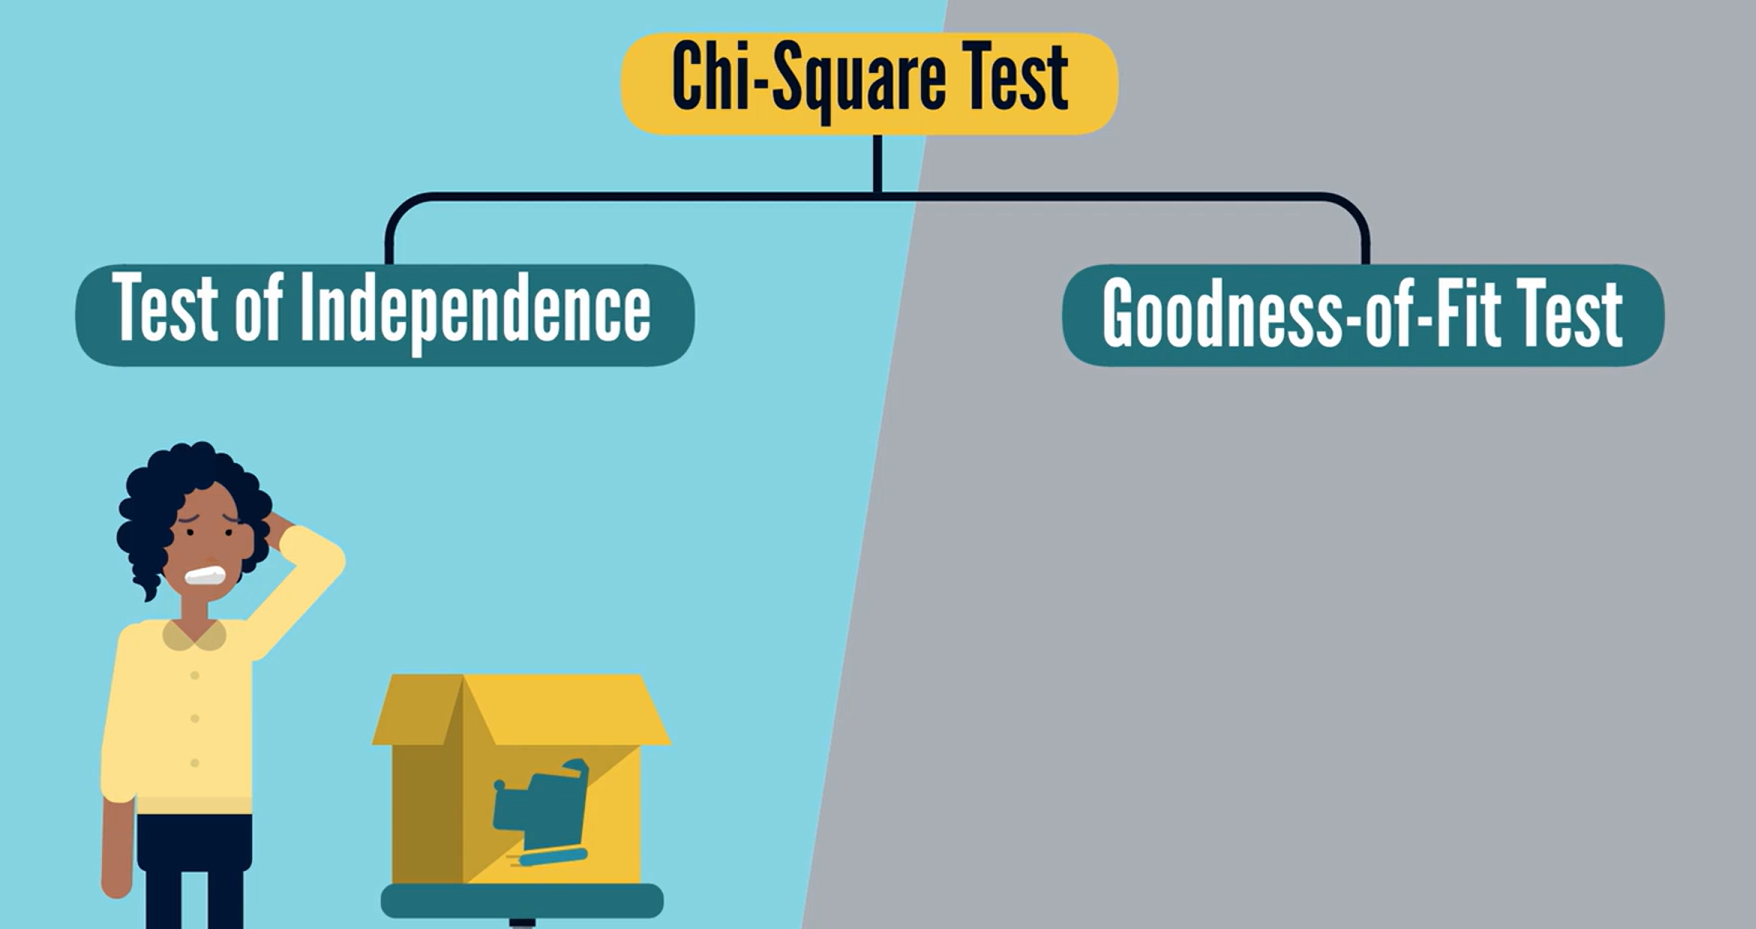

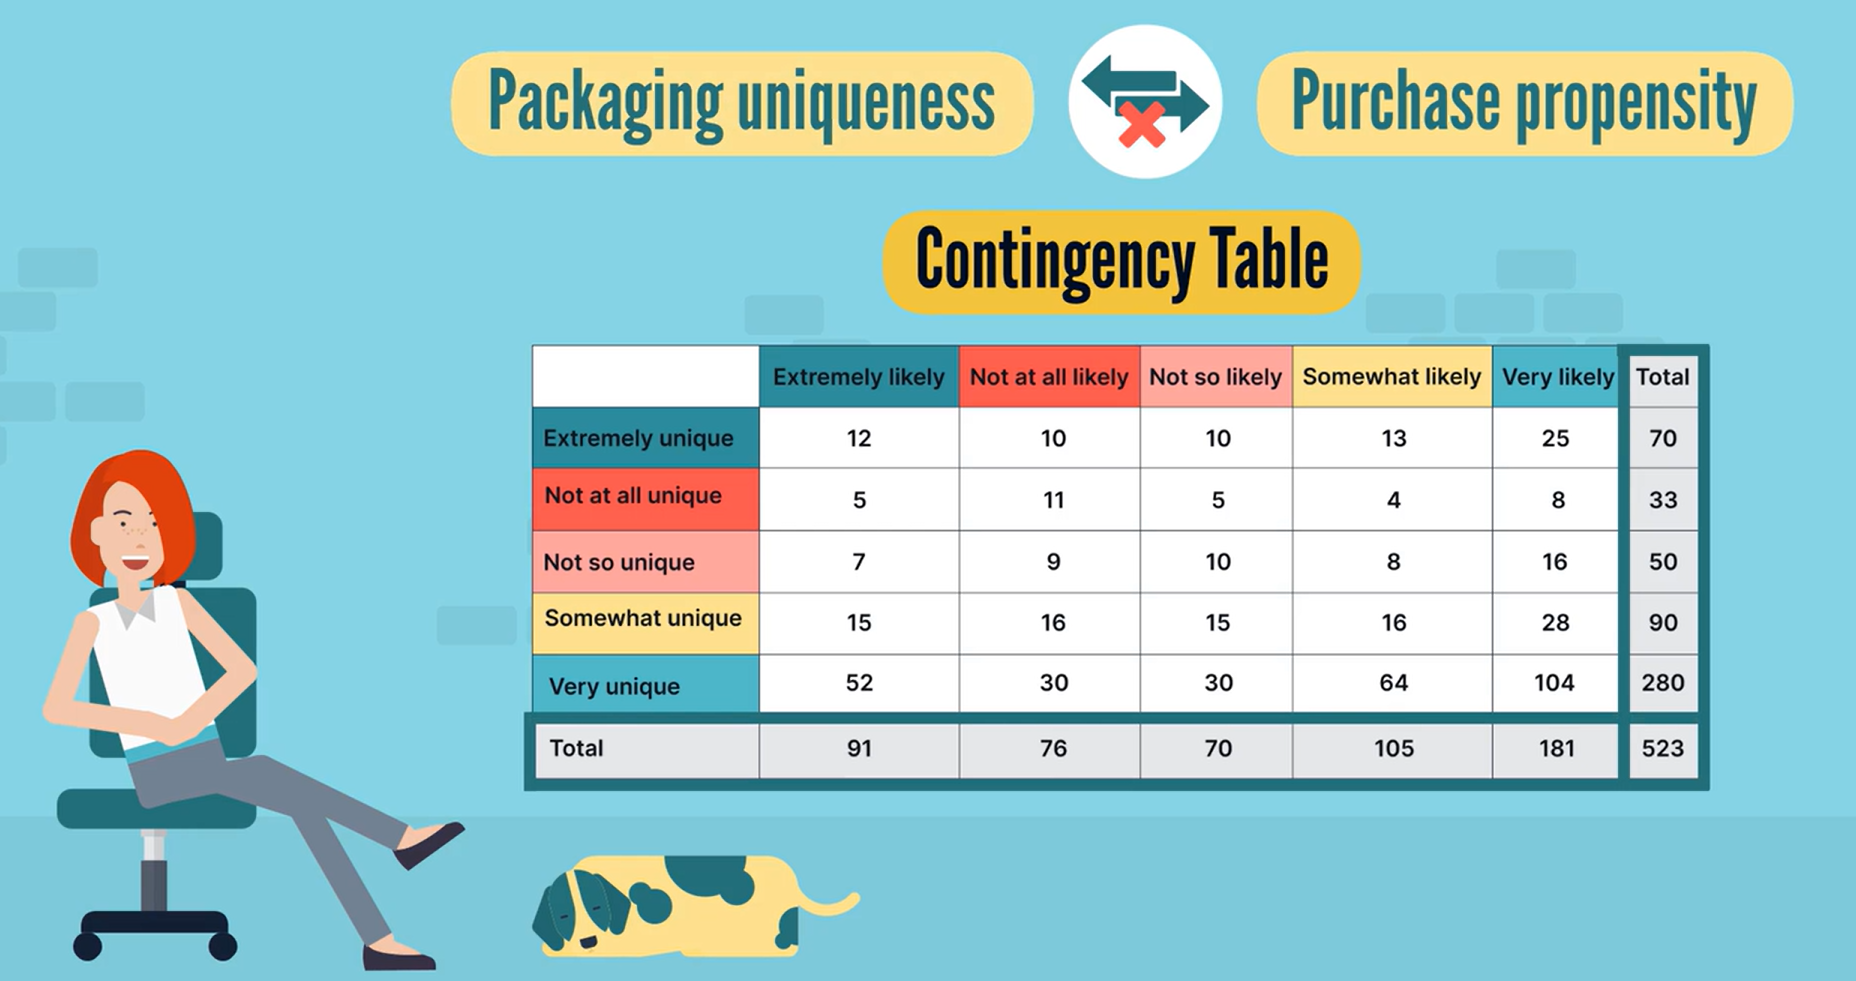

Here, we need to perform the Chi-square Test of Independence.

In [28]:
#Step 14:
# Store the output of the test function into variables
# df_crosstab = pd.crosstab(df["Uniqueness"],df["Purchase Likelihood"])
stat, p, dof, expected = chi2_contingency(df_crosstab, correction=False)

In [25]:
# Display stats
chi2_result = {
    "Chi-square Statistic": stat,
    "Degrees of Freedom": dof,
    "P-Value": p,
    "Expected Frequencies": pd.DataFrame(expected, index=sorter2, columns=sorter)
}
chi2_result

{'Chi-square Statistic': np.float64(21.388569942634078),
 'Degrees of Freedom': 16,
 'P-Value': np.float64(0.16405332505067471),
 'Expected Frequencies':                    Extremely likely  Very likely  Somewhat likely  \
 Extremely unique          12.179732    24.225621        14.053537   
 Very unique               48.718929    96.902486        56.214149   
 Somewhat unique           15.659656    31.147228        18.068834   
 Not so unique              8.699809    17.304015        10.038241   
 Not at all unique          5.741874    11.420650         6.625239   
 
                    Not so likely  Not at all likely  
 Extremely unique        9.369025          10.172084  
 Very unique            37.476099          40.688337  
 Somewhat unique        12.045889          13.078394  
 Not so unique           6.692161           7.265774  
 Not at all unique       4.416826           4.795411  }

In [26]:
# Print results
print("Chi-square Statistic: " + str(stat))
print("P-Value: " + str(p))
print("Degrees of Freedom: " + str(dof))
print("Expected Frequencies: " + str(expected))

Chi-square Statistic: 21.388569942634078
P-Value: 0.16405332505067471
Degrees of Freedom: 16
Expected Frequencies: [[12.17973231 24.22562141 14.05353728  9.36902486 10.17208413]
 [48.71892925 96.90248566 56.21414914 37.47609943 40.68833652]
 [15.65965583 31.14722753 18.06883365 12.0458891  13.07839388]
 [ 8.6998088  17.3040153  10.03824092  6.69216061  7.26577438]
 [ 5.7418738  11.4206501   6.62523901  4.416826    4.79541109]]


In [29]:
# Step 14: Interpretation
alpha = 0.05
if p < alpha:
    result = "✅ Reject the null hypothesis: Uniqueness IS associated with Purchase Likelihood."
else:
    result = "❌ Fail to reject the null hypothesis: No significant relationship between Uniqueness and Purchase Likelihood."

result

'❌ Fail to reject the null hypothesis: No significant relationship between Uniqueness and Purchase Likelihood.'

## **Interpreting the Output**

**The p-value (0.1641) exceeds the pre-established alpha of 0.05. This leads us not to reject the null hypothesis—suggesting no significant link between the product packaging's distinctiveness and the likelihood of consumers purchasing it at a significance level of 0.05.**